<a href="https://colab.research.google.com/github/eacasas/algoritmosOptimizacion/blob/main/music_AI_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from xml.dom import minidom

### 1. Carga de Datos

In [ ]:
import pandas as pd
from xml.dom import minidom

# Leer el archivo XML
library_xml = minidom.parse("./res/rekordbox.xml")
tracks = library_xml.getElementsByTagName("TRACK")

# Crear una lista para almacenar los datos de cada pista
tracks_data = []

# Iterar sobre cada elemento TRACK y crear un diccionario con los datos de interés
for track in tracks:
    track_data = {}
    track_data["id"] = track.getAttribute("TrackID")
    track_data["name"] = track.getAttribute("Name")
    track_data["artist"] = track.getAttribute("Artist")
    track_data["bpm"] = track.getAttribute("AverageBpm")
    track_data["tonality"] = track.getAttribute("Tonality")
    track_data["dateAdd"] = track.getAttribute("DateAdded")
    track_data["album"] = track.getAttribute("Album")
    track_data["label"] = track.getAttribute("Label")
    track_data["comments"] = track.getAttribute("Comments")
    track_data["bitRate"] = track.getAttribute("BitRate")
    track_data["size"] = track.getAttribute("Size")
    track_data["colour"] = track.getAttribute("Colour")
    track_data["playCount"] = track.getAttribute("PlayCount")
    track_data["location"] = track.getAttribute("Location")
    tracks_data.append(track_data)

# Crear el dataframe de Pandas a partir de la lista de diccionarios
library = pd.DataFrame(tracks_data)


In [ ]:
from datetime import datetime

#bpm to number
library['bpm']=pd.to_numeric(library['bpm'], errors='coerce').fillna(0).astype(int)
#convert to date field
format='%Y-%m-%d'
library['dateAdd'] = pd.to_datetime(library['dateAdd'], format=format)

In [ ]:
display(library.head())

,id,name,artist,bpm,tonality,dateAdd,album,label,comments,bitRate,size,colour,playCount,location,key
0,1,Ubi,"Mia Mendi, Thomas Gandey",121,Em,2022-09-07,,,,320,16758117,,3,file://localhost/C:/E+/22T09_Septiembre2/Mia%2...,9A
1,2,Mortero,Yudi Watanabe,120,Fm,2022-09-07,,,,320,18375619,,1,file://localhost/C:/E+/22T09_Septiembre2/Yudi%...,4A
2,3,Pacifica (Capoon Remix),Beije-,123,Em,2022-09-07,,,,320,21617191,,1,file://localhost/C:/E+/22T09_Septiembre2/Beije...,9A
3,4,Away (Original Mix),Losless,123,Bm,2022-09-07,,,,320,17822868,,2,file://localhost/C:/E+/22T09_Septiembre2/Losle...,10A
4,5,Barbak,Olivier Giacomotto,123,Em,2022-09-07,,,,320,16413301,,2,file://localhost/C:/E+/22T09_Septiembre2/Olivi...,9A


#### 1.1 Cambio de tonalidad a clave camelot

In [ ]:
#library['tonality'].unique()

#Camelot Key and tonality equivalence dictionary definition
dic_key_tonality = {'Abm':'1A' ,'B' :'1B',
                    'Ebm':'2A' ,'Gb':'2B',
                    'Bbm':'3A' ,'Db':'3B',
                    'Fm' :'4A' ,'Ab':'4B',
                    'Cm' :'5A' ,'Eb':'5B',
                    'Gm' :'6A' ,'Bb':'6B',
                    'Dm' :'7A' ,'F' :'7B',
                    'Am' :'8A' ,'C' :'8B',
                    'Em' :'9A' ,'G' :'9B',
                    'Bm' :'10A','D' :'10B',
                    'Gbm':'11A','A' :'11B',
                    'Dbm':'12A','E' :'12B'
                    ,'':''}

#Lambda definition
get_key = lambda x: dic_key_tonality[x]
#print(get_key('E'))

In [ ]:
#New column camleto key 
library['key']= library['tonality'].apply(get_key)
library['key'].unique()

array(['9A', '4A', '10A', '2A', '1A', '6A', '5A', '7A', '11A', '8A', '',
       '3A', '6B', '12A', '12B', '4B', '1B', '9B', '2B', '5B', '7B', '8B',
       '11B', '3B', '10B'], dtype=object)

In [ ]:
display(library.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8451 entries, 0 to 8450
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         8451 non-null   object        
 1   name       8451 non-null   object        
 2   artist     8451 non-null   object        
 3   bpm        8451 non-null   int32         
 4   tonality   8451 non-null   object        
 5   dateAdd    2422 non-null   datetime64[ns]
 6   album      8451 non-null   object        
 7   label      8451 non-null   object        
 8   comments   8451 non-null   object        
 9   bitRate    8451 non-null   object        
 10  size       8451 non-null   object        
 11  colour     8451 non-null   object        
 12  playCount  8451 non-null   object        
 13  location   8451 non-null   object        
 14  key        8451 non-null   object        
dtypes: datetime64[ns](1), int32(1), object(13)
memory usage: 957.5+ KB


None

## 2. Grafo Camelot Key


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import graphviz as gv
import pygraphviz

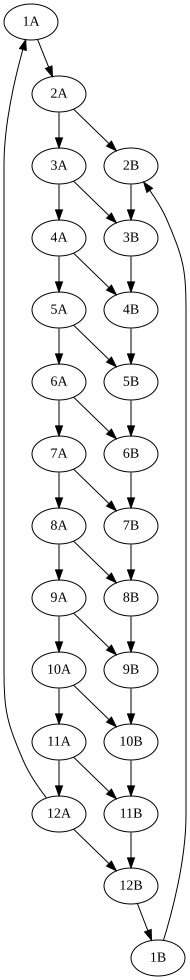

In [ ]:
# Create graph
G = nx.DiGraph()

# Create nodes 
nodos=[]
for i in range (1,13):
    nodos.append(str(i)+"A")
    nodos.append(str(i)+"B")

# Add nodes to graph
G.add_nodes_from(nodos)

# Add edges with weight
#minor notes
G.add_weighted_edges_from([ ("1A", "2A",3),
                            ("2A", "3A",3),
                            ("3A", "4A",3),
                            ("4A", "5A",3),
                            ("5A", "6A",3),
                            ("6A", "7A",3),
                            ("7A", "8A",3),
                            ("8A", "9A",3),
                            ("9A", "10A",3),
                            ("10A", "11A",3),
                            ("11A", "12A",3),
                            ("12A", "1A",3)])

#major notes
G.add_weighted_edges_from([ ("1B", "2B",3),
                            ("2B", "3B",3),
                            ("3B", "4B",3),
                            ("4B", "5B",3),
                            ("5B", "6B",3),
                            ("6B", "7B",3),
                            ("7B", "8B",3),
                            ("8B", "9B",3),
                            ("9B", "10B",3),
                            ("10B", "11B",3),
                            ("11B", "12B",3),
                            ("12B", "1B",3)])

#minior to major
G.add_weighted_edges_from([("2A", "2B",1),
                            ("3A", "3B",1),
                            ("4A", "4B",1),
                            ("5A", "5B",1),
                            ("6A", "6B",1),
                            ("7A", "7B",1),
                            ("8A", "8B",1),
                            ("9A", "9B",1),
                            ("10A", "10B",1),
                            ("11A", "11B",1),
                            ("12A", "12B",1)])

#print(G.nodes(data=True))
#Display graph
A = nx.nx_agraph.to_agraph(G)
A.layout('dot')
gv.Source(A.to_string())

#### 2.1 Sucesores validos

In [ ]:
def getSucesor(G, key):
    successors = list(G.successors(key))    
    d = pd.DataFrame(columns=['key','weight'])

    for node in successors:
        edge_data = G.get_edge_data(key, node)
        weight = edge_data["weight"]        
        d=d.append({'key':node,'weight': weight}, ignore_index=True)

    d=d.sort_values(by='weight', ascending=False)
    return d
    

In [ ]:
key = "6A"
successors = getSucesor(G, key)

display(successors)

,key,weight
0,7A,3
1,6B,1


# 3. Creación play list

In [ ]:
library.query("key == '8A'")

,id,name,artist,bpm,tonality,dateAdd,album,label,comments,bitRate,size,colour,playCount,location,key
22,23,Joy Machine (Original Mix),Brosso & Dub Pepper,120,Am,2022-09-07,,,,320,14390378,0xff007f,3,file://localhost/C:/E+/22T09_Septiembre2/Bross...,8A
57,58,Sidereal (Paul Thomas Extended Remix),Volans & Mango-,122,Am,2022-08-23,,,,320,18297252,0xff0000,2,file://localhost/C:/E+/22T08_Agosto3/Volans%20...,8A
58,59,In Between States (Extended Mix),Levitone,125,Am,2022-08-23,,,,320,19139440,0xff0000,4,file://localhost/C:/E+/22T08_Agosto3/Levitone-...,8A
65,66,Trinity (Extended Mix),Milkwish,124,Am,2022-08-23,,,,320,16250297,0xff007f,2,file://localhost/C:/E+/22T08_Agosto3/Milkwish-...,8A
77,78,Something,I_O,128,Am,2022-08-11,,,,320,12309223,0xff0000,3,file://localhost/C:/E+/22T08_Agosto2/i_o-Somet...,8A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2375,2376,Galacticos (Original Mix),"Pysh, Sincz-",125,Am,2023-01-06,,,,320,6029105,,1,file://localhost/C:/E+/02-DonwloadsAll/202302_...,8A
2394,2395,Stargate (Original Mix),Vincent Vossen-,93,Am,2022-11-21,,,,320,18651472,,2,file://localhost/C:/E+/02-DonwloadsAll/202211_...,8A
2395,2396,Starlight [RedFader],"Maga, Sean Doron-",124,Am,2022-11-21,,,,320,17622248,,2,file://localhost/C:/E+/02-DonwloadsAll/202211_...,8A
2419,2420,SOEL-The Only Reality,,126,Am,2022-10-30,,,,320,14043472,,1,file://localhost/C:/E+/01-MinusTechMelody/08-O...,8A


In [ ]:
# first song

def get_first_song(library,key='8A',bpm_max=122):
    #beging 8A
    filter = f" key == '{key}' and bpm < {bpm_max}"
    first_song=library.query(filter).sample(n=1)
    return first_song

In [ ]:
display(get_first_song(library))

,id,name,artist,bpm,tonality,dateAdd,album,label,comments,bitRate,size,colour,playCount,location,key
714,715,Fall Away,"Armen Miran, Nicolas Rada",120,Am,2021-08-07,Corner of the Room,Balance Music,,320,18237182,0xffa500,6,file://localhost/C:/E+/20T08_Agosto/Armen%20Mi...,8A
